**EfficientNet Model Performance**  

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Total Dataset: 5216
Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

===== Fold 1 =====
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 79s 153ms/step - accuracy: 0.4740 - auc: 0.5017 - loss: 0.7516
Epoch 2/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 24s 59ms/step - accuracy: 0.4731 - auc: 0.4655 - loss: 0.7689
Epoch 3/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.4958 - auc: 0.4946 - loss: 0.7555
Epoch 4/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.4973 - auc: 0.4873 - loss: 0.7532
Epoch 5/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.5045 - auc: 0.5012 - loss: 0.7443
Epoch 6/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.4973 - auc: 0.4815 - loss: 0.7519
Epoch 7/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 24s 60ms/step - accuracy: 0.5007 - auc: 0.4809 - loss: 0.7524
Epoch 8/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 2

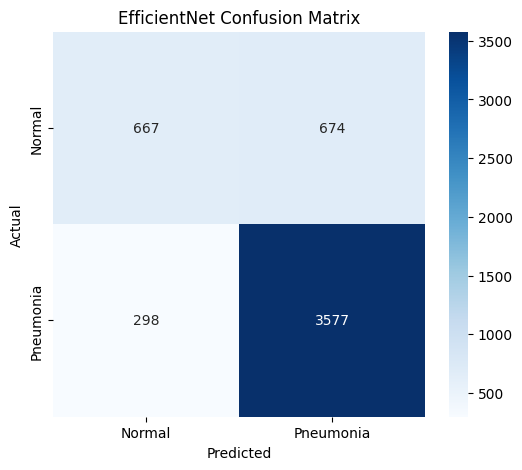

In [1]:
# ==========================================
# 1. IMPORTS
# ==========================================
import tensorflow as tf
import numpy as np
import os, glob

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.utils import class_weight

import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# ==========================================
# LOAD DATASET (FIXED)
# ==========================================
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

data_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(data_dir, "train")

normal_paths = glob.glob(train_dir + "/NORMAL/*.jpeg")
pneumonia_paths = glob.glob(train_dir + "/PNEUMONIA/*.jpeg")

all_paths = np.array(normal_paths + pneumonia_paths)
labels = np.array([0]*len(normal_paths) + [1]*len(pneumonia_paths))

print("Total Dataset:", len(all_paths))

# ==========================================
# 3. PARAMETERS
# ==========================================
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img/255.0, label

# ==========================================
# 4. CLASS WEIGHTS
# ==========================================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ==========================================
# 5. MODEL
# ==========================================
def build_model():
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(224,224,3))
    base.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model, base

def fine_tune(model, base_model, layers=60):
    base_model.trainable = True

    for layer in base_model.layers[:-layers]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(1e-5),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ==========================================
# 6. CROSS VALIDATION
# ==========================================
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

all_true = []
all_pred_prob = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, labels)):

    print(f"\n===== Fold {fold+1} =====")

    train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

    train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(1)
    val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(1)

    # MODEL
    model, base = build_model()

    model.fit(train_ds, epochs=8, class_weight=class_weights, verbose=1)

    model = fine_tune(model, base, 60)
    model.fit(train_ds, epochs=5, class_weight=class_weights, verbose=1)

    pred = model.predict(val_ds).flatten()

    print("Fold AUC:", roc_auc_score(val_labels, pred))

    all_true.extend(val_labels)
    all_pred_prob.extend(pred)

    tf.keras.backend.clear_session()

# ==========================================
# 7. THRESHOLD OPTIMIZATION
# ==========================================
y_true = np.array(all_true)
y_prob = np.array(all_pred_prob)

best_t, best_f1 = 0.5, 0

for t in np.arange(0.4, 0.8, 0.01):
    pred = (y_prob > t).astype(int)
    f1 = f1_score(y_true, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("\nBest Threshold:", best_t)

y_pred = (y_prob > best_t).astype(int)

# ==========================================
# 8. FINAL METRICS
# ==========================================
print("\nAccuracy:", np.mean(y_true == y_pred))
print("AUC:", roc_auc_score(y_true, y_prob))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# ==========================================
# 9. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"],
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNet Confusion Matrix")
plt.show()

**MobileNet Model Performance**

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Balanced: 2682

===== Fold 1 =====
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 52s 162ms/step - accuracy: 0.6174 - auc: 0.6641 - loss: 0.6991
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.7002 - auc: 0.7616 - loss: 0.5963
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.7718 - auc: 0.8457 - loss: 0.5123
Epoch 1/2
112/112 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.7662 - auc: 0.8622 - loss: 0.5154
Epoch 2/2
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8686 - auc: 0.9385 - loss: 0.3710
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 365ms/step
Fold AUC: 0.9875380988844346

===== Fold 2 =====
Epoch 1/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 30s 83ms/step - accuracy: 0.5078 - auc: 0.5099 - loss: 0.8274
Epoch 2/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 16s 38ms/step - accuracy: 0.6119 - auc: 0.6641 - loss: 0.6822
Epoch 3/3
112/112 ━━━━━━━━━━━━━━━━━━━━ 16

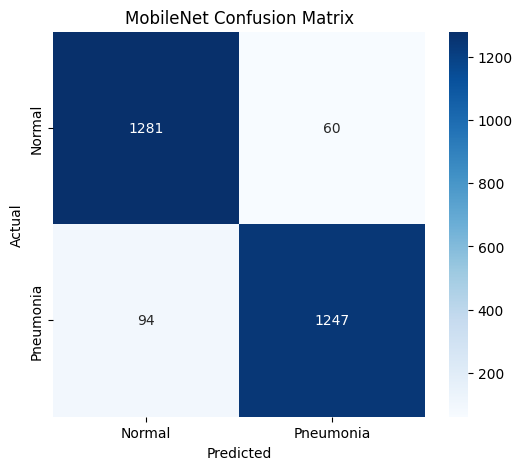

In [ ]:
# ================================
# 1. INSTALL
# ================================
!pip install kagglehub -q

import tensorflow as tf
import numpy as np
import os, glob, random
import kagglehub

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score

import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# ================================
# 2. DATASET (SAME PIPELINE)
# ================================
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

data_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(data_dir, "train")

normal_paths = glob.glob(train_dir + "/NORMAL/*.jpeg")
pneumonia_paths = glob.glob(train_dir + "/PNEUMONIA/*.jpeg")

# Balanced sampling
pneumonia_paths = random.sample(pneumonia_paths, len(normal_paths))

all_paths = np.array(normal_paths + pneumonia_paths)
labels = np.array([0]*len(normal_paths) + [1]*len(pneumonia_paths))

print("Balanced:", len(all_paths))

# ================================
# 3. PARAMETERS
# ================================
IMG_SIZE = 224
BATCH_SIZE = 16

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img/255.0, label

# ================================
# 4. MODEL BUILDER
# ================================
def build_model(base_model):
    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.4)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(base_model.input, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ================================
# 5. FINE-TUNING
# ================================
def fine_tune(model, base_model, layers=30):
    base_model.trainable = True

    for layer in base_model.layers[:-layers]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(1e-5),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ================================
# 6. CROSS VALIDATION
# ================================
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

all_true = []
all_pred_prob = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, labels)):

    print(f"\n===== Fold {fold+1} =====")

    train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

    train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE)
    val_ds = val_ds.map(load_image).batch(BATCH_SIZE)

    # ---------------- MobileNet ----------------
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(224,224,3))
    model = build_model(base)

    # Initial training
    model.fit(train_ds, epochs=3, verbose=1)

    # Fine-tuning
    model = fine_tune(model, base, 30)
    model.fit(train_ds, epochs=2, verbose=1)

    preds = model.predict(val_ds).flatten()

    all_true.extend(val_labels)
    all_pred_prob.extend(preds)

    print("Fold AUC:", roc_auc_score(val_labels, preds))

    tf.keras.backend.clear_session()

# ================================
# 7. THRESHOLD OPTIMIZATION
# ================================
y_true = np.array(all_true)
y_prob = np.array(all_pred_prob)

best_t, best_f1 = 0.5, 0

for t in np.arange(0.3, 0.9, 0.05):
    pred = (y_prob > t).astype(int)
    f1 = f1_score(y_true, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("\nBest Threshold:", best_t)

y_pred = (y_prob > best_t).astype(int)

# ================================
# 8. RESULTS
# ================================
print("\nAccuracy:", np.mean(y_true == y_pred))
print("AUC:", roc_auc_score(y_true, y_prob))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# ================================
# 9. CONFUSION MATRIX
# ================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"],
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNet Confusion Matrix")
plt.show()

**Ensemble Model (MobileNet + EfficientNet)**

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Total Dataset: 5216
Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}

===== Fold 1 =====
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 35s 66ms/step - accuracy: 0.5870 - auc: 0.6733 - loss: 0.7715
Epoch 2/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 37s 67ms/step - accuracy: 0.6713 - auc: 0.7668 - loss: 0.6691
Epoch 3/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7219 - auc: 0.8243 - loss: 0.5898
Epoch 4/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7328 - auc: 0.8307 - loss: 0.5816
Epoch 5/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.7567 - auc: 0.8580 - loss: 0.5300
Epoch 6/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 40s 65ms/step - accuracy: 0.7783 - auc: 0.8699 - loss: 0.5133
Epoch 7/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 25s 66ms/step - accuracy: 0.7840 - auc: 0.8739 - loss: 0.5025
Epoch 8/8
218/218 ━━━━━━━━━━━━━━━━━━━━ 42s 

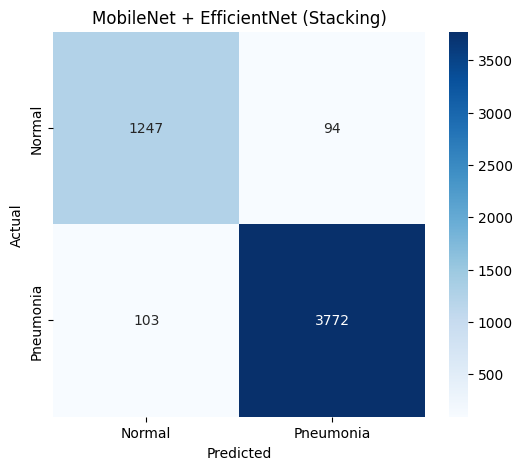

In [2]:
# ==========================================
# 1. INSTALL & IMPORTS
# ==========================================
!pip install kagglehub -q

import tensorflow as tf
import numpy as np
import os, glob
import kagglehub

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

# ==========================================
# 2. LOAD DATASET
# ==========================================
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

data_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(data_dir, "train")

normal_paths = glob.glob(train_dir + "/NORMAL/*.jpeg")
pneumonia_paths = glob.glob(train_dir + "/PNEUMONIA/*.jpeg")

all_paths = np.array(normal_paths + pneumonia_paths)
labels = np.array([0]*len(normal_paths) + [1]*len(pneumonia_paths))

print("Total Dataset:", len(all_paths))

# ==========================================
# 3. PARAMETERS + AUGMENTATION
# ==========================================
IMG_SIZE = 224
BATCH_SIZE = 16

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

# ==========================================
# 4. MODEL BUILDERS
# ==========================================
def build_mobilenet():
    base = MobileNetV2(weights='imagenet', include_top=False,
                       input_shape=(224,224,3))
    base.trainable = False

    x = base.output
    x = data_augmentation(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model, base


def build_efficientnet():
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(224,224,3))
    base.trainable = False

    x = base.output
    x = data_augmentation(x)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(base.input, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model, base

# ==========================================
# 5. FINE-TUNING
# ==========================================
def fine_tune(model, base_model, layers=60):
    base_model.trainable = True

    for layer in base_model.layers[:-layers]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(1e-5),
        loss=BinaryCrossentropy(label_smoothing=0.05),
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

# ==========================================
# 6. CLASS WEIGHTS
# ==========================================
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ==========================================
# 7. CROSS VALIDATION
# ==========================================
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

all_true = []
all_pred_prob = []

for fold, (train_idx, val_idx) in enumerate(skf.split(all_paths, labels)):

    print(f"\n===== Fold {fold+1} =====")

    train_paths, val_paths = all_paths[train_idx], all_paths[val_idx]
    train_labels, val_labels = labels[train_idx], labels[val_idx]

    train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
    val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

    train_ds = train_ds.map(load_image).shuffle(1000).batch(BATCH_SIZE).prefetch(1)
    val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(1)

    # ================= MobileNet =================
    model_mob, base_mob = build_mobilenet()
    model_mob.fit(train_ds, epochs=8, class_weight=class_weights, verbose=1)

    model_mob = fine_tune(model_mob, base_mob, 60)
    model_mob.fit(train_ds, epochs=5, class_weight=class_weights, verbose=1)

    pred_mob = model_mob.predict(val_ds).flatten()

    # ================= EfficientNet =================
    model_eff, base_eff = build_efficientnet()
    model_eff.fit(train_ds, epochs=8, class_weight=class_weights, verbose=1)

    model_eff = fine_tune(model_eff, base_eff, 60)
    model_eff.fit(train_ds, epochs=5, class_weight=class_weights, verbose=1)

    pred_eff = model_eff.predict(val_ds).flatten()

    # ================= STACKING =================
    X_meta = np.vstack([pred_mob, pred_eff]).T

    meta_model = LogisticRegression()
    meta_model.fit(X_meta, val_labels)

    ensemble = meta_model.predict_proba(X_meta)[:,1]

    all_true.extend(val_labels)
    all_pred_prob.extend(ensemble)

    print("Fold AUC:", roc_auc_score(val_labels, ensemble))

    tf.keras.backend.clear_session()

# ==========================================
# 8. THRESHOLD OPTIMIZATION
# ==========================================
y_true = np.array(all_true)
y_prob = np.array(all_pred_prob)

best_t, best_f1 = 0.5, 0

for t in np.arange(0.4, 0.8, 0.01):
    pred = (y_prob > t).astype(int)
    f1 = f1_score(y_true, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("\nBest Threshold:", best_t)

y_pred = (y_prob > best_t).astype(int)

# ==========================================
# 9. FINAL METRICS
# ==========================================
print("\nAccuracy:", np.mean(y_true == y_pred))
print("AUC:", roc_auc_score(y_true, y_prob))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

# ==========================================
# 10. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Pneumonia"],
            yticklabels=["Normal","Pneumonia"],
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNet + EfficientNet (Stacking)")
plt.show()